In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/retail_sales_dataset.csv', encoding='latin1')
df.shape


(1000, 9)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [6]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [7]:
df.describe()


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [8]:
df.describe(include='object')


,Customer ID,Gender,Product Category
count,1000,1000,1000
unique,1000,2,3
top,CUST1000,Female,Clothing
freq,1,510,351


In [9]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].median()



,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [10]:
df[numeric_cols].mode().iloc[0]

,0
Transaction ID,1.0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


In [11]:
#Step 3: Time series analysis

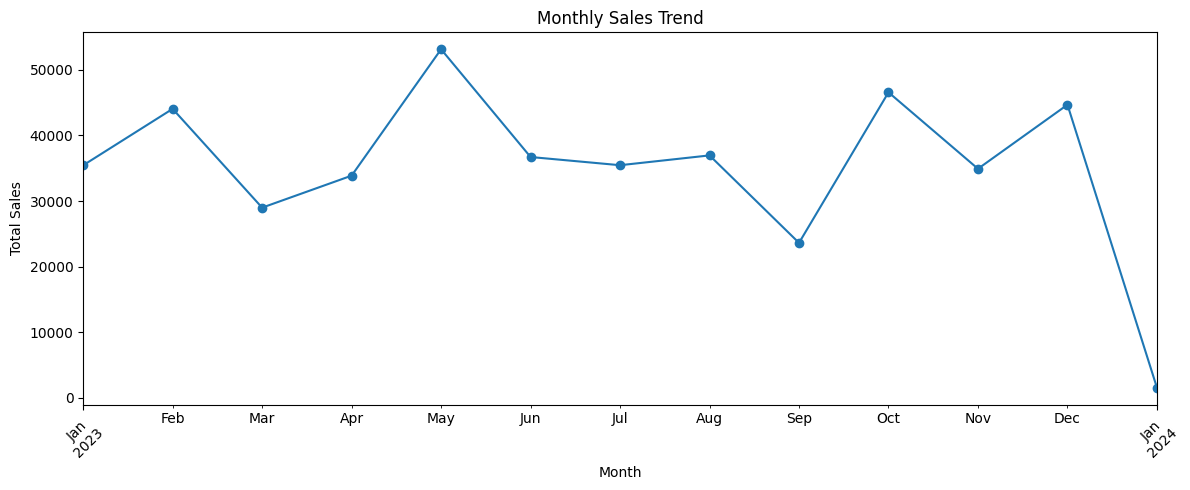

In [12]:

df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

monthly_sales = df.groupby('Month')['Total Amount'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Observation: The 46-55 age group has the highest customer count  . Customers under 18 are
a very small segment (20), suggesting the customer base skews toward
established, higher-earning adults rather than very young shoppers.

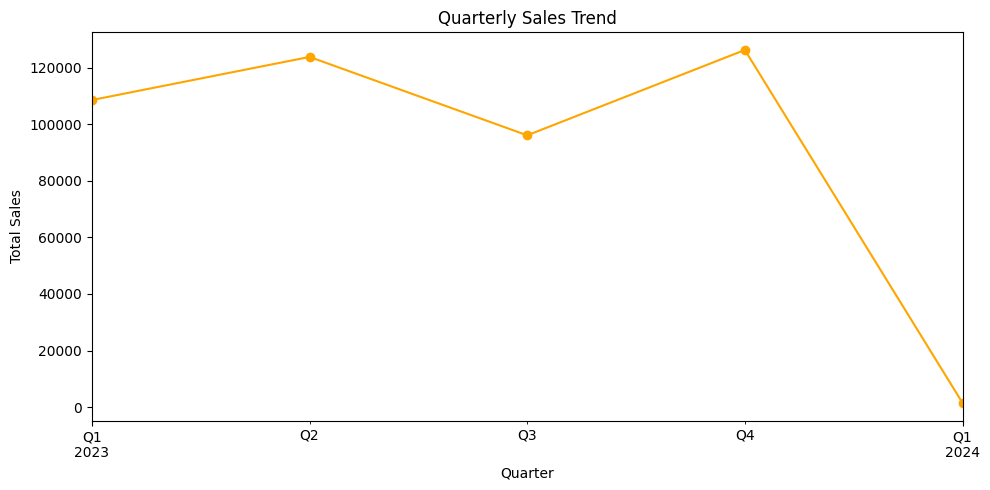

In [13]:

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()
plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='line', marker='o', color='orange')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

Observation: Q4 is the strongest quarter overall (₹126,000), closely
followed by Q2 (₹124,000), while Q3 dips to ₹96,000. Q1 2024 appears
near-zero only because the dataset ends in January, not because of an
actual sales collapse.

/tmp/ipykernel_5665/1250018936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette='pastel')


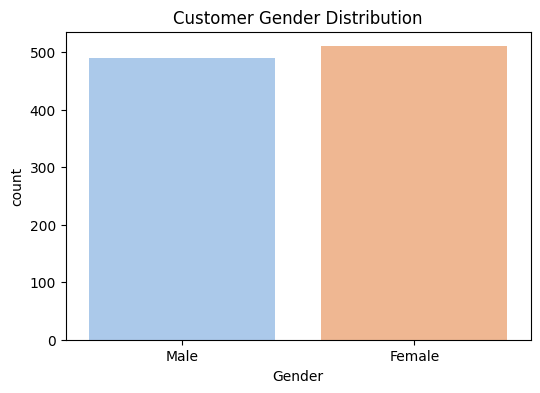

Gender Percentage:
Gender
Female    51.0
Male      49.0
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Gender', palette='pastel')

plt.title('Customer Gender Distribution')
plt.show()

print("Gender Percentage:")
print(df['Gender'].value_counts(normalize=True) * 100)

Observation: [  "Male customers
make up 51% and Female 49%"]

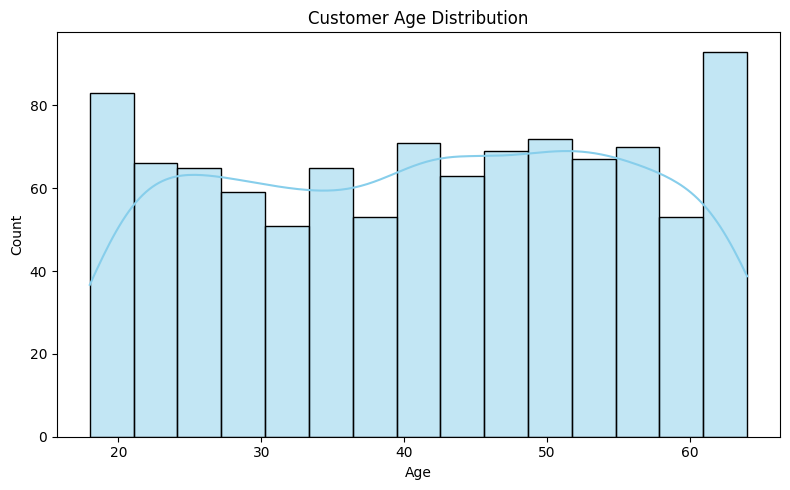

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True, color='skyblue')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

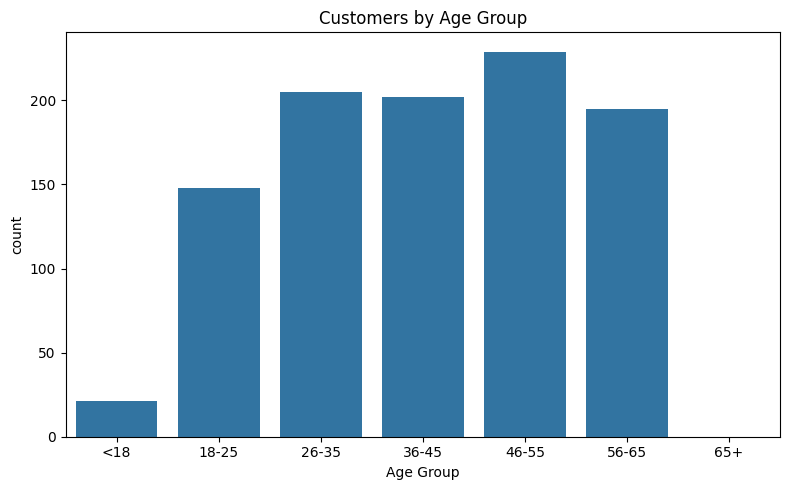

In [16]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Age Group')

plt.title('Customers by Age Group')
plt.tight_layout()
plt.show()

Observation: The 46-55 age group is the largest customer segment
(225 customers), followed by 26-35 and 36-45 (200-205 each). Customers
under 18 are a very small segment (20)

In [17]:
#PRODUCT ANALYSIS - TASK 1

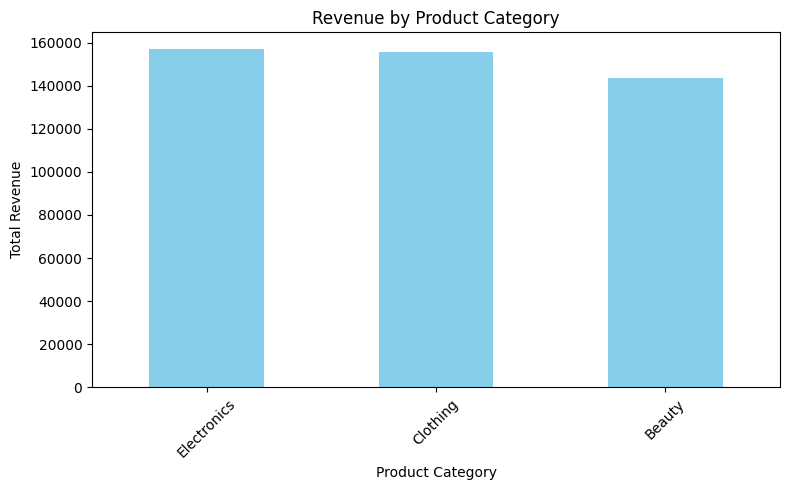

In [18]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_revenue.plot(kind='bar', color='skyblue')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation:Electronics generates the highest revenue, while Beauty
trails as the lowest-earning category. This gap suggests Beauty may be
underpromoted or under-stocked relative to demand.

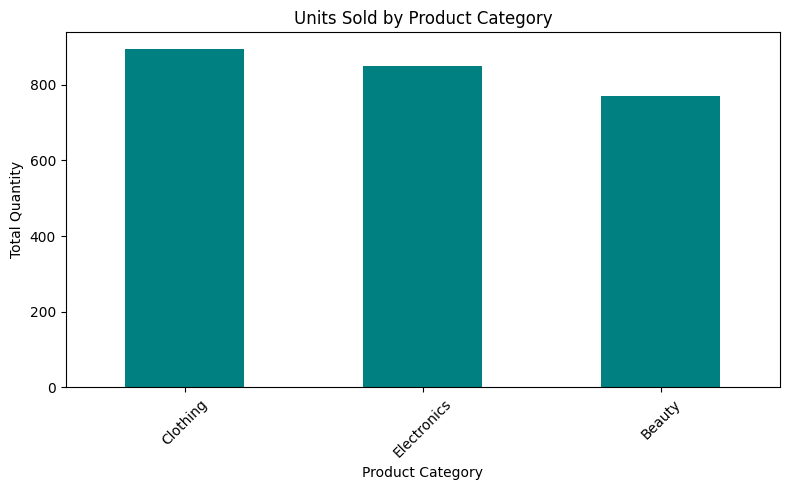

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [19]:
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_qty.plot(kind='bar', color='teal')
plt.title('Units Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(category_revenue)
print(category_qty)

Observation: Clothing has the highest number of units sold (800 above), yet Electronics generates the most revenue overall — indicating Electronics items carry a much higher price per unit, so fewer units still translate into greater revenue. Beauty is the weakest category on both units sold  and revenue.

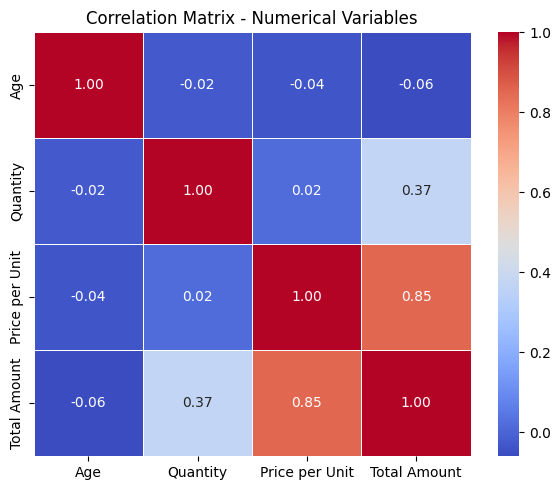

In [20]:
plt.figure(figsize=(6,5))
corr = df[['Age','Quantity','Price per Unit','Total Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Numerical Variables')
plt.tight_layout()
plt.show()

Observation: Price per Unit correlates strongly with Total Amount
(0.85), as expected since Total Amount is derived from price and quantity. Quantity shows only a moderate correlation (0.37), and Age shows almost no correlation with any variable, suggesting age isn't a strong driver of purchase amount or basket size.

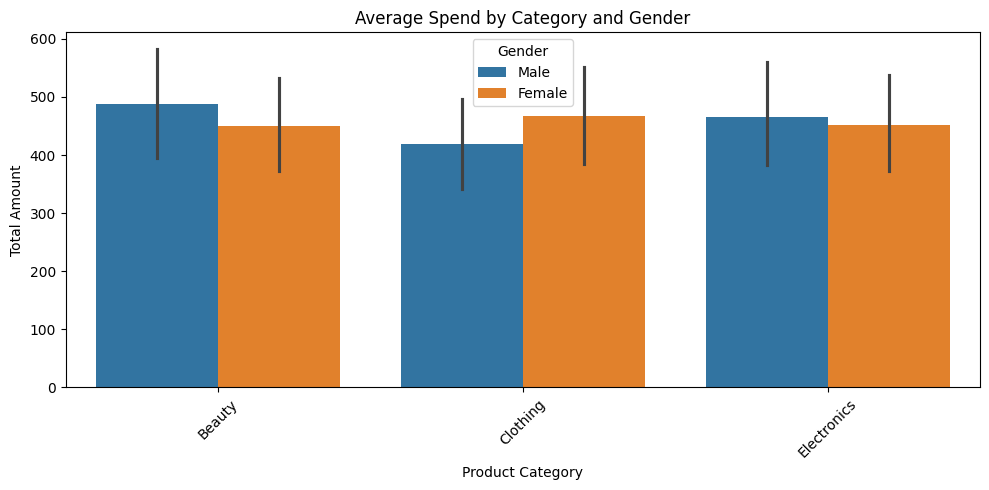

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Product Category', y='Total Amount', hue='Gender', estimator='mean')
plt.title('Average Spend by Category and Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observation: Males spend more on average in Beauty and Electronics,
while Females spend more in Clothing. However, the wide, overlapping
confidence intervals across genders suggest these differences aren't
strongly conclusive with this sample size.

In [22]:
df['Customer ID'].duplicated().sum()

np.int64(0)